# Statistical Audit of pandas-dev/pandas

## Member Information
- **Name:** Ahmad Aqil Fadria
- **Role:** Data Engineer

---

# Research Questions

1. What is the estimated probability that a pull request gets merged in pandas-dev/pandas?

2. Has the average issue closing duration changed significantly after a major pandas release?

3. What is the probability that a randomly selected issue takes longer than 30 days to close?

---

# AI Usage Disclosure

**Member:** Ahmad Aqil Fadria — Data Engineer  
**Tools used:** ChatGPT

| Task | Tool | Prompt Summary | Output Modified? |
|---|---|---|---|
| GitHub API collection workflow | ChatGPT | GitHub issues API data collection | Yes |
| EDA notebook structure | ChatGPT | Statistical EDA notebook structure | Yes |

**Written entirely without AI:**
- Interpretation markdown cells
- EDA conclusions

---

# Import Libraries

In [29]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# GitHub API Configuration

This section defines the repository information and API endpoint
used to collect issue data from the pandas-dev/pandas repository.

In [ ]:
OWNER = "pandas-dev"
REPO = "pandas"

BASE_URL = f"https://api.github.com/repos/{OWNER}/{REPO}/issues"

# GitHub Personal Access Token
TOKEN = "ghp_xxxxxxxxxxxx"

headers = {
    "Authorization": f"token {TOKEN}",
    "Accept": "application/vnd.github+json"
}


# Collect Issues Data

This section collects issue data from the GitHub REST API.
The dataset includes open and closed issues from the repository.

In [31]:
all_issues = []

for page in range(1, 31):

    url = (
        f"{BASE_URL}"
        f"?state=all&per_page=100&page={page}"
    )

    response = requests.get(
        url,
        headers=headers
    )


    if response.status_code != 200:
        print(f"Error collecting page {page}")
        break

    data = response.json()

    if len(data) == 0:
        break

    all_issues.extend(data)

    print(f"Collected page {page}")
    print("Total raw data:",
      len(all_issues))

Collected page 1
Total raw data: 100
Collected page 2
Total raw data: 200
Collected page 3
Total raw data: 300
Collected page 4
Total raw data: 400
Collected page 5
Total raw data: 500
Collected page 6
Total raw data: 600
Collected page 7
Total raw data: 700
Collected page 8
Total raw data: 800
Collected page 9
Total raw data: 900
Collected page 10
Total raw data: 1000
Collected page 11
Total raw data: 1100
Collected page 12
Total raw data: 1200
Collected page 13
Total raw data: 1300
Collected page 14
Total raw data: 1400
Collected page 15
Total raw data: 1500
Collected page 16
Total raw data: 1600
Collected page 17
Total raw data: 1700
Collected page 18
Total raw data: 1800
Collected page 19
Total raw data: 1900
Collected page 20
Total raw data: 2000
Collected page 21
Total raw data: 2100
Collected page 22
Total raw data: 2200
Collected page 23
Total raw data: 2300
Collected page 24
Total raw data: 2400
Collected page 25
Total raw data: 2500
Collected page 26
Total raw data: 2600
Coll

# Convert to DataFrame

The collected JSON data is converted into a pandas DataFrame
for further processing and analysis.

In [32]:
df = pd.DataFrame(all_issues)

print(df.shape)

(3000, 37)


# Save Raw Dataset

The original dataset is saved without modification
to preserve the raw GitHub API data.

In [33]:
df.to_csv("../data/raw/issues_raw.csv", index=False)

print("Raw dataset saved.")

Raw dataset saved.


# Filter True Issues

The GitHub issues endpoint also contains pull requests.
This section filters only actual issues.

In [34]:
# ============================================================
# CLEAN ISSUE DATA
# ============================================================

issues_df = df.copy()

# ambil hanya closed
issues_df = issues_df[
    issues_df["state"] == "closed"
].copy()

print(issues_df.shape)

(2537, 37)


# Select Important Columns

Only relevant columns are selected for statistical analysis.

In [35]:
issues_df = issues_df[
    [
        "id",
        "number",
        "title",
        "state",
        "created_at",
        "closed_at",
        "comments"
    ]
]

# Datetime Conversion

Datetime columns are converted into pandas datetime format
to enable duration analysis.

In [36]:
issues_df["created_at"] = pd.to_datetime(
    issues_df["created_at"]
)

issues_df["closed_at"] = pd.to_datetime(
    issues_df["closed_at"]
)

# Feature Engineering

This section creates new variables for statistical analysis.

In [37]:
issues_df["close_duration_days"] = (
    issues_df["closed_at"] - issues_df["created_at"]
).dt.days

issues_df["is_closed"] = 1

# Save Clean Dataset

The cleaned dataset is saved for use in
subsequent statistical analysis layers.

In [38]:
issues_df.to_csv(
    "../data/clean/dataset.csv",
    index=False
)

# Dataset Overview

This section provides a general overview
of the cleaned dataset.

In [39]:
issues_df.head()

,id,number,title,state,created_at,closed_at,comments,close_duration_days,is_closed
2,4539481199,65743,PERF: Fix performance regression in to_julian_...,closed,2026-05-28 09:58:29+00:00,2026-05-28 16:40:32+00:00,1,0,1
8,4526140043,65736,CI: Bump pixi to 0.69,closed,2026-05-26 17:26:40+00:00,2026-05-26 18:33:46+00:00,1,0,1
12,4517506050,65732,Backport PR #65731 on branch 3.0.x (DOC: start...,closed,2026-05-25 14:10:22+00:00,2026-05-26 13:06:13+00:00,0,0,1
13,4517400089,65731,DOC: start 3.0.4 whatsnew notes,closed,2026-05-25 13:53:44+00:00,2026-05-25 14:09:52+00:00,0,0,1
15,4516764518,65729,Bump github/codeql-action from 4.35.5 to 4.36.0,closed,2026-05-25 12:05:11+00:00,2026-05-26 16:16:53+00:00,0,1,1


In [40]:
issues_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2537 entries, 2 to 2999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   id                   2537 non-null   int64              
 1   number               2537 non-null   int64              
 2   title                2537 non-null   object             
 3   state                2537 non-null   object             
 4   created_at           2537 non-null   datetime64[ns, UTC]
 5   closed_at            2537 non-null   datetime64[ns, UTC]
 6   comments             2537 non-null   int64              
 7   close_duration_days  2537 non-null   int64              
 8   is_closed            2537 non-null   int64              
dtypes: datetime64[ns, UTC](2), int64(5), object(2)
memory usage: 198.2+ KB


In [41]:
issues_df.describe()

,id,number,comments,close_duration_days,is_closed
count,2.537000e+03,2537.000000,2537.000000,2537.000000,2537.0
mean,3.945821e+09,64142.368940,1.921955,10.823413,1.0
std,2.593293e+08,848.206096,2.998984,25.387291,0.0
min,3.517745e+09,62702.000000,0.000000,0.000000,1.0
25%,3.743460e+09,63414.000000,1.000000,0.000000,1.0
50%,3.927613e+09,64120.000000,1.000000,1.000000,1.0
75%,4.136520e+09,64840.000000,2.000000,8.000000,1.0
max,4.539481e+09,65743.000000,81.000000,201.000000,1.0


# Missing Values Analysis

This section checks whether the dataset
contains missing values.

In [42]:
issues_df.isnull().sum()

id                     0
number                 0
title                  0
state                  0
created_at             0
closed_at              0
comments               0
close_duration_days    0
is_closed              0
dtype: int64

# Visualization: Closing Duration Distribution

This histogram shows the distribution
of issue closing duration in days.

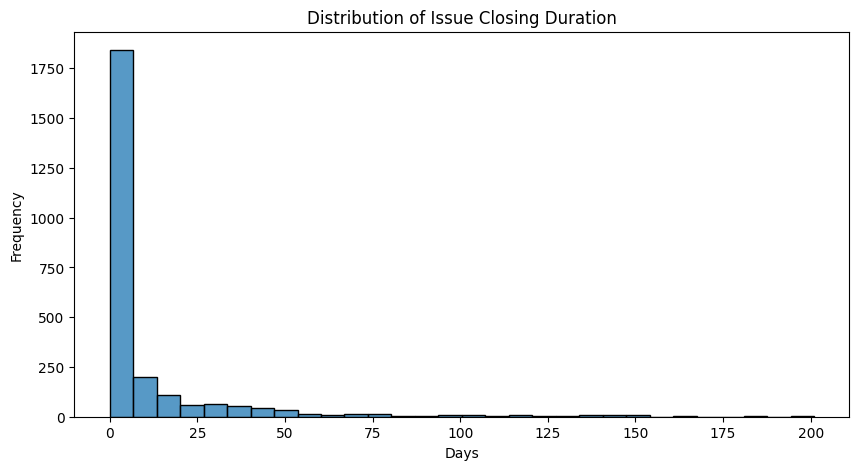

In [43]:
plt.figure(figsize=(10, 5))

sns.histplot(
    issues_df["close_duration_days"],
    bins=30
)

plt.title("Distribution of Issue Closing Duration")
plt.xlabel("Days")
plt.ylabel("Frequency")

plt.show()

# Visualization: Issue Status Count

This visualization compares the number
of open and closed issues.

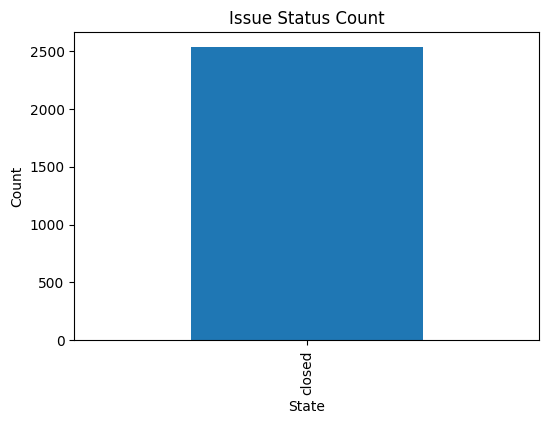

In [44]:
plt.figure(figsize=(6, 4))

issues_df["state"].value_counts().plot(
    kind="bar"
)

plt.title("Issue Status Count")
plt.xlabel("State")
plt.ylabel("Count")

plt.show()

# Visualization: Issues Created Over Time

This visualization shows issue activity trends over time.

C:\Users\USER\AppData\Local\Temp\ipykernel_21396\248647077.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


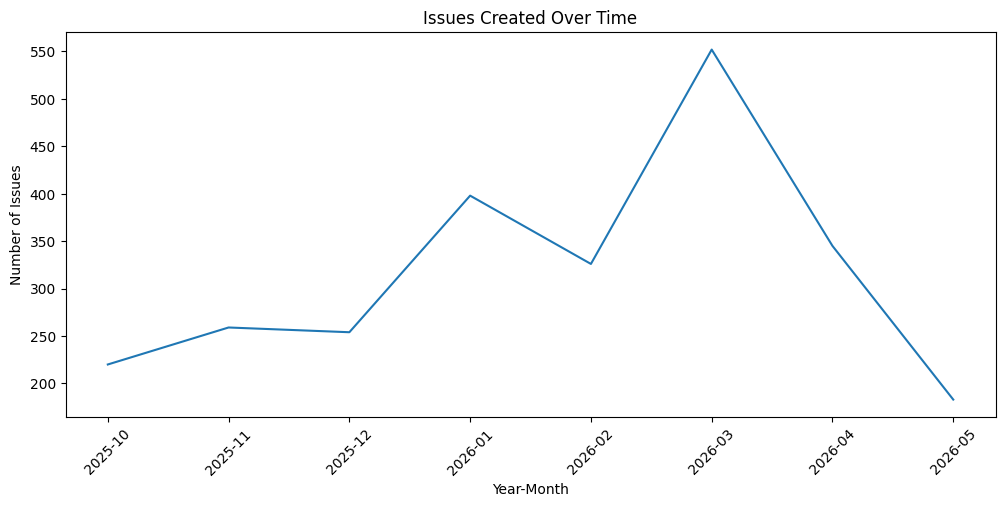

In [45]:
issues_df["year_month"] = (
    issues_df["created_at"]
    .dt.to_period("M")
    .astype(str)
)

monthly_issues = (
    issues_df["year_month"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 5))

monthly_issues.plot()

plt.title("Issues Created Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Number of Issues")

plt.xticks(rotation=45)

plt.show()

# Variable Selection

The following variables are selected
for subsequent statistical analysis.

In [46]:
variable_selection = pd.DataFrame({
    "Variable": [
        "is_closed",
        "close_duration_days",
        "comments"
    ],
    "Statistical Usage": [
        "Bernoulli Estimation",
        "Confidence Interval & Hypothesis Testing",
        "Poisson Analysis"
    ]
})

variable_selection

,Variable,Statistical Usage
0,is_closed,Bernoulli Estimation
1,close_duration_days,Confidence Interval & Hypothesis Testing
2,comments,Poisson Analysis


# Pull Request Data Collection

This section collects pull request data
from the pandas-dev/pandas repository
using the GitHub REST API.

The pull request dataset will later support:
- Bernoulli MLE
- merge probability estimation
- confidence interval construction
- statistical hypothesis testing

In [47]:
PR_URL = f"https://api.github.com/repos/{OWNER}/{REPO}/pulls"

all_prs = []

for page in range(1, 6):

    url = (
        f"{PR_URL}"
        f"?state=all&per_page=100&page={page}"
    )

    response = requests.get(url)

    if response.status_code != 200:
        print(f"Error collecting PR page {page}")
        break

    data = response.json()

    if len(data) == 0:
        break

    all_prs.extend(data)

    print(f"Collected PR page {page}")

print(f"Total PR collected: {len(all_prs)}")



Collected PR page 1
Collected PR page 2
Collected PR page 3
Collected PR page 4
Collected PR page 5
Total PR collected: 500


# Convert Pull Request Data to DataFrame

This section converts the collected pull request
JSON data into a pandas DataFrame for processing
and analysis.

In [48]:
pr_df = pd.DataFrame(all_prs)

print(pr_df.shape)

pr_df.head()

(500, 36)


,url,id,node_id,html_url,diff_url,patch_url,issue_url,number,state,locked,...,review_comment_url,comments_url,statuses_url,head,base,_links,author_association,auto_merge,assignee,active_lock_reason
0,https://api.github.com/repos/pandas-dev/pandas...,3763514552,PR_kwDOAA0YD87gUqy4,https://github.com/pandas-dev/pandas/pull/65745,https://github.com/pandas-dev/pandas/pull/6574...,https://github.com/pandas-dev/pandas/pull/6574...,https://api.github.com/repos/pandas-dev/pandas...,65745,open,False,...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,{'label': 'man-group:rmorotti-bug-resample-unw...,"{'label': 'pandas-dev:main', 'ref': 'main', 's...",{'self': {'href': 'https://api.github.com/repo...,CONTRIBUTOR,None,None,None
1,https://api.github.com/repos/pandas-dev/pandas...,3762922219,PR_kwDOAA0YD87gSaLr,https://github.com/pandas-dev/pandas/pull/65744,https://github.com/pandas-dev/pandas/pull/6574...,https://github.com/pandas-dev/pandas/pull/6574...,https://api.github.com/repos/pandas-dev/pandas...,65744,open,False,...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,{'label': 'jorisvandenbossche:obj-to-json-get_...,"{'label': 'pandas-dev:main', 'ref': 'main', 's...",{'self': {'href': 'https://api.github.com/repo...,MEMBER,None,None,None
2,https://api.github.com/repos/pandas-dev/pandas...,3761171973,PR_kwDOAA0YD87gLu4F,https://github.com/pandas-dev/pandas/pull/65743,https://github.com/pandas-dev/pandas/pull/6574...,https://github.com/pandas-dev/pandas/pull/6574...,https://api.github.com/repos/pandas-dev/pandas...,65743,closed,False,...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,"{'label': 'rhshadrach:perf_to_julian', 'ref': ...","{'label': 'pandas-dev:main', 'ref': 'main', 's...",{'self': {'href': 'https://api.github.com/repo...,MEMBER,None,None,None
3,https://api.github.com/repos/pandas-dev/pandas...,3760806588,PR_kwDOAA0YD87gKVq8,https://github.com/pandas-dev/pandas/pull/65742,https://github.com/pandas-dev/pandas/pull/6574...,https://github.com/pandas-dev/pandas/pull/6574...,https://api.github.com/repos/pandas-dev/pandas...,65742,open,False,...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,"{'label': 'QuLogic:mpl311', 'ref': 'mpl311', '...","{'label': 'pandas-dev:main', 'ref': 'main', 's...",{'self': {'href': 'https://api.github.com/repo...,CONTRIBUTOR,None,None,None
4,https://api.github.com/repos/pandas-dev/pandas...,3751445995,PR_kwDOAA0YD87fmoXr,https://github.com/pandas-dev/pandas/pull/65739,https://github.com/pandas-dev/pandas/pull/6573...,https://github.com/pandas-dev/pandas/pull/6573...,https://api.github.com/repos/pandas-dev/pandas...,65739,open,False,...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,{'label': 'Alvaro-Kothe:fix/window-corr-numeri...,"{'label': 'pandas-dev:main', 'ref': 'main', 's...",{'self': {'href': 'https://api.github.com/repo...,MEMBER,None,None,None


# Save Raw Pull Request Dataset

This section stores the original pull request dataset
without modification.

Output:
- data/raw/pull_requests_raw.csv

In [49]:
pr_df.to_csv(
    "../data/raw/pull_requests_raw.csv",
    index=False
)

print("pull_requests_raw.csv saved.")

pull_requests_raw.csv saved.


# Pull Request Data Cleaning

This section cleans the pull request dataset
and selects relevant variables for statistical analysis.

Cleaning includes:
- selecting relevant columns
- datetime conversion
- handling missing values
- feature engineering

In [50]:
pr_clean = pr_df[
    [
        "id",
        "number",
        "state",
        "created_at",
        "closed_at",
        "merged_at"
    ]
].copy()

print(pr_clean.shape)

pr_clean.head()

(500, 6)


,id,number,state,created_at,closed_at,merged_at
0,3763514552,65745,open,2026-05-28T16:50:00Z,None,None
1,3762922219,65744,open,2026-05-28T15:10:32Z,None,None
2,3761171973,65743,closed,2026-05-28T09:58:29Z,2026-05-28T16:40:32Z,2026-05-28T16:40:32Z
3,3760806588,65742,open,2026-05-28T08:51:31Z,None,None
4,3751445995,65739,open,2026-05-26T22:55:25Z,None,None


# Datetime Conversion

This section converts timestamp variables
into datetime format for duration analysis
and statistical computation.

In [51]:
pr_clean["created_at"] = pd.to_datetime(
    pr_clean["created_at"]
)

pr_clean["closed_at"] = pd.to_datetime(
    pr_clean["closed_at"]
)

pr_clean["merged_at"] = pd.to_datetime(
    pr_clean["merged_at"]
)

# Pull Request Feature Engineering

This section creates additional variables
required for statistical analysis.

Generated variables:
- merged
- review_duration_days

In [52]:
# merged PR indicator
pr_clean["merged"] = (
    pr_clean["merged_at"].notna()
).astype(int)

# review duration
pr_clean["review_duration_days"] = (
    pr_clean["closed_at"] - pr_clean["created_at"]
).dt.days

pr_clean.head()

,id,number,state,created_at,closed_at,merged_at,merged,review_duration_days
0,3763514552,65745,open,2026-05-28 16:50:00+00:00,NaT,NaT,0,NaN
1,3762922219,65744,open,2026-05-28 15:10:32+00:00,NaT,NaT,0,NaN
2,3761171973,65743,closed,2026-05-28 09:58:29+00:00,2026-05-28 16:40:32+00:00,2026-05-28 16:40:32+00:00,1,0.0
3,3760806588,65742,open,2026-05-28 08:51:31+00:00,NaT,NaT,0,NaN
4,3751445995,65739,open,2026-05-26 22:55:25+00:00,NaT,NaT,0,NaN


# Save Clean Pull Request Dataset

This section exports the cleaned pull request dataset
for use by subsequent statistical analysis layers.

Output:
- data/clean/pr_dataset.csv

In [53]:
pr_clean.to_csv(
    "../data/clean/pr_dataset.csv",
    index=False
)

print("pr_dataset.csv saved.")

pr_dataset.csv saved.


# Visualization: Pull Request Merge Status

This visualization shows the number of merged
and non-merged pull requests in the repository.

This variable is important for:
- Bernoulli estimation
- merge probability analysis
- confidence interval construction

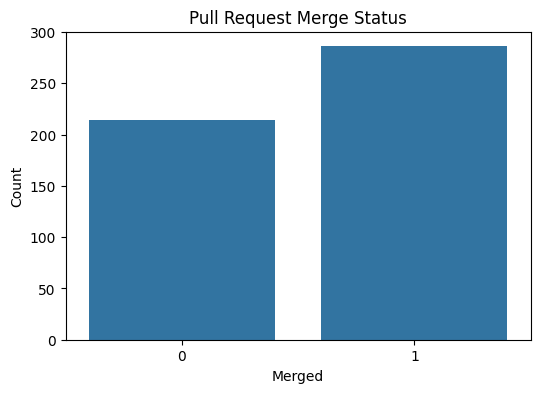

In [54]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="merged",
    data=pr_clean
)

plt.title("Pull Request Merge Status")
plt.xlabel("Merged")
plt.ylabel("Count")

plt.show()

# Visualization: Pull Request Review Duration

This visualization explores how long pull requests
take to be reviewed and closed.

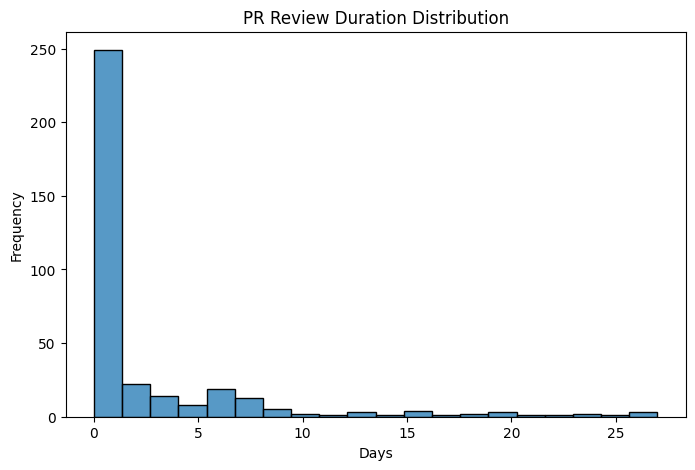

In [55]:
plt.figure(figsize=(8,5))

sns.histplot(
    pr_clean["review_duration_days"].dropna(),
    bins=20
)

plt.title("PR Review Duration Distribution")
plt.xlabel("Days")
plt.ylabel("Frequency")

plt.show()

# Summary

This notebook successfully completed the data engineering
workflow for the statistical audit of the pandas-dev/pandas
GitHub repository.

The workflow included:
- collecting GitHub issue data
- collecting pull request data
- storing raw datasets
- cleaning and preprocessing datasets
- feature engineering
- exploratory data analysis (EDA)
- generating statistical visualizations

Datasets generated in this notebook:

Raw datasets:
- data/raw/issues_raw.csv
- data/raw/pull_requests_raw.csv

Clean datasets:
- data/clean/dataset.csv
- data/clean/pr_dataset.csv

Key variables prepared for further statistical analysis:
- issue closing duration
- issue activity frequency
- pull request merge status
- pull request review duration

The cleaned datasets produced in this notebook
will be used by the next analysis layers:
- parameter estimation
- confidence interval construction
- hypothesis testing
- computational simulation

This notebook establishes the foundational data pipeline
required for all subsequent statistical analyses in the project.